In [74]:
# Geometric Intuition
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import f1_score

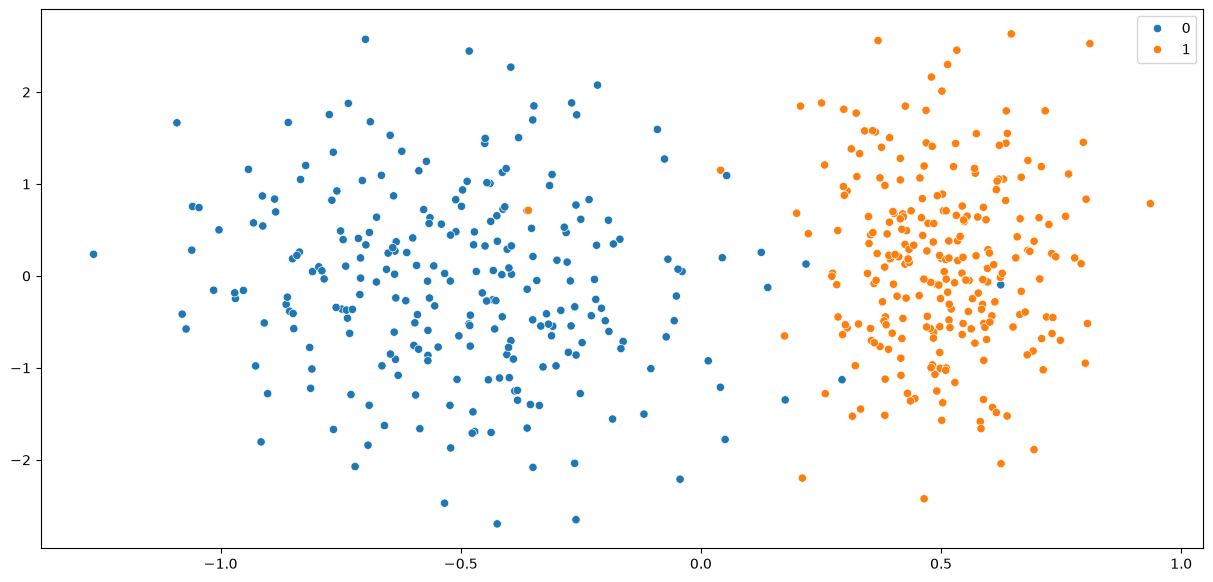

In [75]:
X, y = make_classification(
    n_samples = 500,
    n_features = 2,
    n_informative = 1,
    n_redundant = 0,
    n_classes = 2,
    n_clusters_per_class = 1,
    class_sep = 0.5,
    random_state = 42
)

plt.figure(figsize=(15, 7))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.show()

In [76]:
class Perceptron:
    def __init__(self, lr: float, epochs: int, input_shape: int) -> None:
        self.coef_: np.ndarray = np.random.randn(input_shape) # Weights for input features
        self.intercept_ = 0                            # Bias term
        
        self.lr = lr            # Learning rate
        self.epochs = epochs    # Number of training iterations

    def activation(self, fx):
        return 1 if fx > 0 else 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        for _ in range(self.epochs):

            for idx in np.random.permutation(X_train.shape[0]):

                y_hat_internal: float = self.activation(np.dot(X_train[idx], self.coef_) + self.intercept_) # There is a need of step function here else the co-ordinates of point gets scaled (100 [y_pred] - 0 [y_train]) = 100 * point co-ordinates.

                # Same as gradient optimization
                self.coef_ -= self.lr * (y_hat_internal - y_train[idx]) * X_train[idx]
                self.intercept_ -= self.lr * (y_hat_internal - y_train[idx]) * 1 # always put 1 because there is no term in 'x - (point)' to subtract

    def predict(self, X_test):
        # Calculate weighted sum + bias
        ans: float = np.dot(X_test, self.coef_) + self.intercept_
        return np.where(ans >= 0, 1, 0) # Use >= 0 for the positive class (1) based on standard perceptron

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [78]:
model_1st = Perceptron(0.01, 500, input_shape=X_train.shape[1])
model_1st.fit(X_train, y_train)

print(model_1st.intercept_)
print(model_1st.coef_)

-0.010000000000000004
[ 0.06165884 -0.00855547]


In [79]:
f1_score(y_test, model_1st.predict(X_test))

0.946236559139785

In [80]:
model_2nd = Perceptron(0.01, 500, input_shape=X_train.shape[1])
model_2nd.fit(X_train, y_train)

model_3rd = Perceptron(0.01, 500, input_shape=X_train.shape[1])
model_3rd.fit(X_train, y_train)

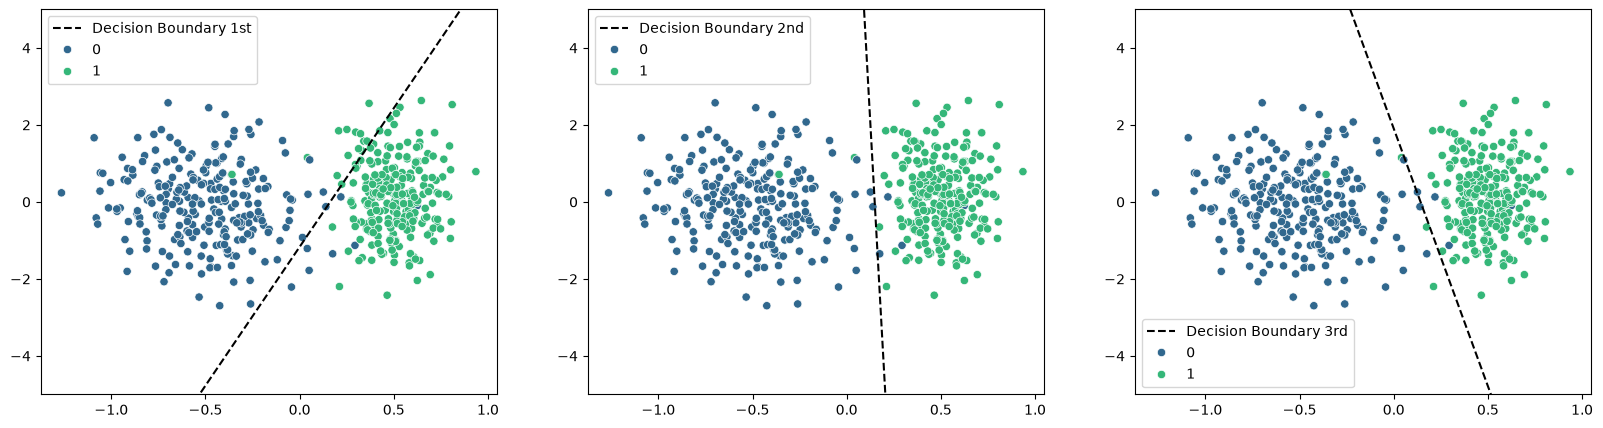

In [81]:
# Assuming X is your feature matrix and y is the target array
# Calculate the decision boundary
weight_1st = -model_1st.coef_[0] / model_1st.coef_[1]
bias_1st = -model_1st.intercept_ / model_1st.coef_[1]

weight_2nd = -model_2nd.coef_[0] / model_2nd.coef_[1]
bias_2nd = -model_2nd.intercept_ / model_2nd.coef_[1]

weight_3rd = -model_3rd.coef_[0] / model_3rd.coef_[1]
bias_3rd = -model_3rd.intercept_ / model_3rd.coef_[1]

# Create a range of values for the decision boundary plot
temp_x1: np.ndarray = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Decision boundary equation
temp_x2_1st = weight_1st * temp_x1 + bias_1st
temp_x2_2nd = weight_2nd * temp_x1 + bias_2nd
temp_x2_3rd = weight_3rd * temp_x1 + bias_3rd

# Plot the decision boundary
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

# Plot decision boundary
ax[0].plot(temp_x1, temp_x2_1st, 'k--', label='Decision Boundary 1st')
ax[1].plot(temp_x1, temp_x2_2nd, 'k--', label='Decision Boundary 2nd')
ax[2].plot(temp_x1, temp_x2_3rd, 'k--', label='Decision Boundary 3rd')

# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full', ax=ax[0])
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full', ax=ax[1])
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full', ax=ax[2])

# Add a legend and show the plot
ax[0].set_ylim(-5, 5)
ax[1].set_ylim(-5, 5)
ax[2].set_ylim(-5, 5)
plt.show()
# You can see the randomness in decision boundaries

Observation → The changes in the best fit line are one way, means if there is a missclassification then only the coefficients of best fit like will update.

In [82]:
class Perceptron:
    def __init__(self, lr: float, epochs: int, input_shape: int) -> None:
        self.coef_: np.ndarray = np.random.randn(input_shape) # Weights for input features
        self.intercept_: float = 0                            # Bias term
        
        self.lr = lr            # Learning rate
        self.epochs = epochs    # Number of training iterations

    def activation(self, fx):
        return np.exp(fx) / (1 + np.exp(fx))

    def fit(self, X_train: np.ndarray, y_train_original: np.ndarray):
        for _ in range(self.epochs):

            for idx in np.random.permutation(X_train.shape[0]):

                y_hat_internal: float = self.activation(np.dot(X_train[idx], self.coef_) + self.intercept_) # There is a need of step function here else the co-ordinates of point gets scaled (100 [y_pred] - 0 [y_train]) = 100 * point co-ordinates.

                # Same as gradient optimization
                self.coef_ -= self.lr * (y_hat_internal - y_train[idx]) * X_train[idx]
                self.intercept_ -= self.lr * (y_hat_internal - y_train[idx]) * 1 # always put 1 because there is no term in 'x - (point)' to subtract

    def predict(self, X_test):
        # Calculate weighted sum + bias
        ans: float = np.dot(X_test, self.coef_) + self.intercept_
        return np.where(ans >= 0, 1, 0) # Use >= 0 for the positive class (1) based on standard perceptron

In [83]:
model_1st = Perceptron(0.01, 500, input_shape=X_train.shape[1])
model_1st.fit(X_train, y_train)

print(model_1st.intercept_)
print(model_1st.coef_)

-1.2502347390067656
[12.08934832  0.52734597]


In [84]:
f1_score(y_test, model_1st.predict(X_test))

0.9896907216494846

In [85]:
model_2nd = Perceptron(0.01, 500, input_shape=X_train.shape[1])
model_2nd.fit(X_train, y_train)

model_3rd = Perceptron(0.01, 500, input_shape=X_train.shape[1])
model_3rd.fit(X_train, y_train)

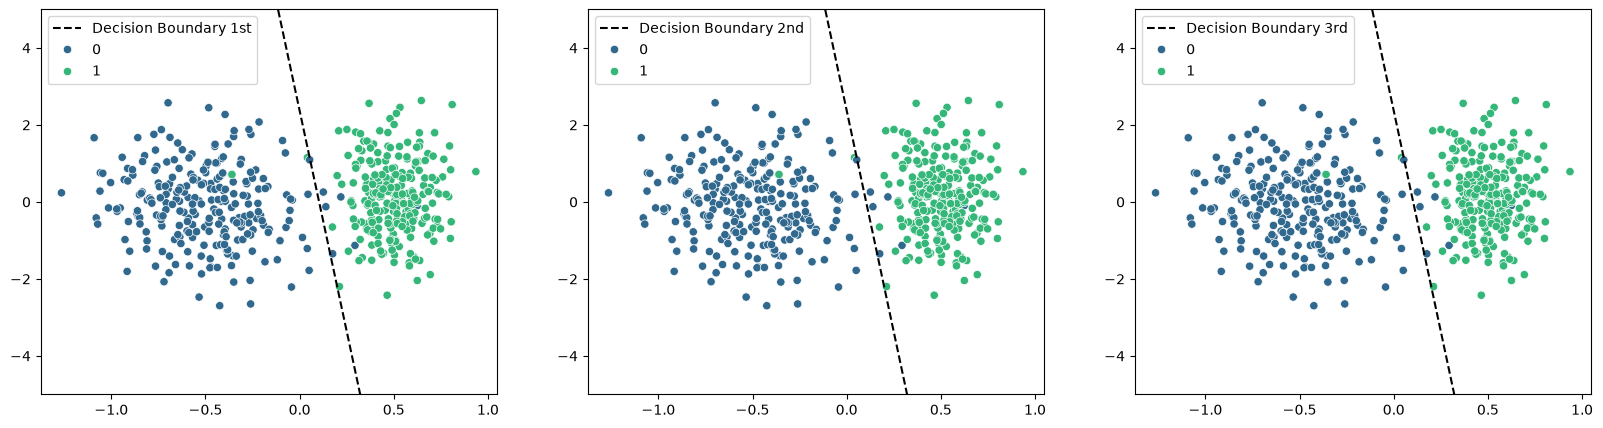

In [86]:
# Assuming X is your feature matrix and y is the target array
# Calculate the decision boundary
weight_1st = -model_1st.coef_[0] / model_1st.coef_[1]
bias_1st = -model_1st.intercept_ / model_1st.coef_[1]

weight_2nd = -model_2nd.coef_[0] / model_2nd.coef_[1]
bias_2nd = -model_2nd.intercept_ / model_2nd.coef_[1]

weight_3rd = -model_3rd.coef_[0] / model_3rd.coef_[1]
bias_3rd = -model_3rd.intercept_ / model_3rd.coef_[1]

# Create a range of values for the decision boundary plot
temp_x1: np.ndarray = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Decision boundary equation
temp_x2_1st = weight_1st * temp_x1 + bias_1st
temp_x2_2nd = weight_2nd * temp_x1 + bias_2nd
temp_x2_3rd = weight_3rd * temp_x1 + bias_3rd

# Plot the decision boundary
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

# Plot decision boundary
ax[0].plot(temp_x1, temp_x2_1st, 'k--', label='Decision Boundary 1st')
ax[1].plot(temp_x1, temp_x2_2nd, 'k--', label='Decision Boundary 2nd')
ax[2].plot(temp_x1, temp_x2_3rd, 'k--', label='Decision Boundary 3rd')

# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full', ax=ax[0])
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full', ax=ax[1])
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full', ax=ax[2])

# Add a legend and show the plot
ax[0].set_ylim(-5, 5)
ax[1].set_ylim(-5, 5)
ax[2].set_ylim(-5, 5)
plt.show()
# You can see the similarity in decision boundaries

Observation → The changes in the best fit line are two way, means if there is both classification or missclassification then the coefficients of best fit like will update in-order to increase / decrease there probabilities of corrosponding classes.

<hr>

In [87]:
from sklearn.linear_model import Perceptron

model = Perceptron(
    penalty=None, # Regularization parameter l2' or 'l1' or None
    alpha=0.0001, # Regularization Coefficient
    fit_intercept=True, # Calculate the intercept or not
    max_iter=1000, # Number of Iterations for GD
    tol=1e-3, # The convergence threshold. If the diff of the loss between two consecutive epochs is less than tol, convergence is assumed.
    shuffle=True, # Whether or not the training data should be shuffled after each epoch
    verbose=False, # Training phase printing
    eta0=0.01, # Learning Rate
    n_jobs=-1,
    random_state=42,
    validation_fraction=0.2, # The proportion of training data to set aside as validation set for early stopping
    n_iter_no_change=5 # The number of iterations with no improvement to wait before early stopping
)

# How validation_fraction works: If the model's performance on the validation set doesn't improve for a certain number of epochs (set by n_iter_no_change), training stops early to prevent overfitting.

In [88]:
model.fit(X_train, y_train)

,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.2
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True


In [89]:
print(model.coef_)
print(model.intercept_)

[[0.08201616 0.00853332]]
[-0.01]


In [90]:
f1_score(y_test, model.predict(X_test))

1.0

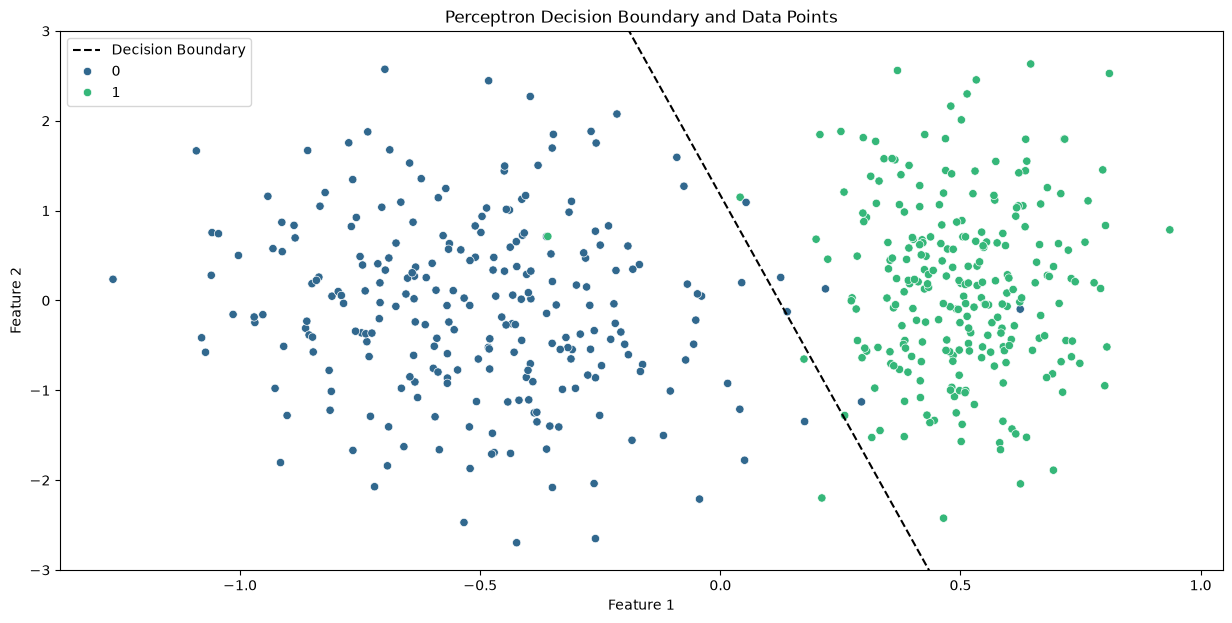

In [91]:
# Assuming X is your feature matrix and y is the target array
# Calculate the decision boundary
weight = -model.coef_[0][0] / model.coef_[0][1]
bias = -model.intercept_ / model.coef_[0][1]

# Create a range of values for the decision boundary plot
temp_x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Decision boundary equation
temp_x2 = weight * temp_x1 + bias

# Plot the decision boundary
plt.figure(figsize=(15, 7))

# Plot decision boundary
plt.plot(temp_x1, temp_x2, 'k--', label='Decision Boundary')

# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full')

# Label the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary and Data Points')

# Add a legend and show the plot
plt.ylim(-3, 3)
plt.legend()
plt.show()

---

In [92]:
# Gradient Optimization
class Perceptron:
    def __init__(self, input_shape: int, epochs: int, lr: float) -> None:
        self.parameters: np.ndarray = np.random.randn(1, input_shape)
        self.bias: np.ndarray = np.zeros(shape=(1, 1))

        # Gradient Descent parameters
        self.epochs = epochs
        self.lr = lr

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.dot(X, self.parameters.T) + self.bias

    def train(self, X_train: np.ndarray, y_train: np.ndarray) -> None:
        n = X_train.shape[0]

        for epoch in range(self.epochs):
            scores: np.ndarray = self.predict(X_train) # Unbounded
            margin = y_train * scores # Bounded [-1 or 1] → product [-10, 4.9, 23, -67, 3 ....]

            # Hinge loss gradient mask: only update misclassified points
            """
                1 * 1 (classified) → 1
                -1 * -1 (classified) → 1
                1 * -1 (missclassified) → -1
                -1 * 1 (missclassified) → -1

                We want -1 (missclassified records) → Thats why margin < 0
            """
            mask = (margin < 0).astype(float) # (n, 1)

            # Batch gradient of hinge loss
            dw = -(mask * y_train).T @ X_train
            db = -np.sum(mask * y_train, axis=0)

            self.parameters -= self.lr * dw
            self.bias -= self.lr * db

            if (epoch+1) % 100 == 0: # After every 100th epoch we are calculating the loss
                # Hinge Loss
                term = -1 * y_train * np.where(scores >= 0, 1, -1)
                hinge_loss = np.sum(np.where(term > 0, term , 0))

                print(f"Epoch {epoch+1} Hinge Loss: {hinge_loss:.4f}")
    
    def evaluate(self, X_test: np.array, y_test):
        y_pred: np.ndarray = self.predict(X = X_test)
        y_pred_class: np.ndarray = np.where(y_pred >= 0, 1, -1)

        accuracy = (y_test == y_pred_class).sum() / len(X_test)
        return accuracy

In [93]:
y: np.ndarray = np.where(y == 0, -1, y).reshape(-1, 1)
model: Perceptron = Perceptron(X.shape[1], 500, 0.01)
model.train(X, y)

print("\nLearned weight:", model.parameters.flatten())
print("Learned bias:", model.bias)
# print("Predictions:", np.sign(model.predict(X)).flatten())

print(f"Training Accuracy = {model.evaluate(X_test=X, y_test=y)}")

Epoch 100 Hinge Loss: 7.0000
Epoch 200 Hinge Loss: 8.0000
Epoch 300 Hinge Loss: 7.0000
Epoch 400 Hinge Loss: 6.0000
Epoch 500 Hinge Loss: 7.0000

Learned weight: [0.61862804 0.0414478 ]
Learned bias: [[-0.08]]
Training Accuracy = 0.984
